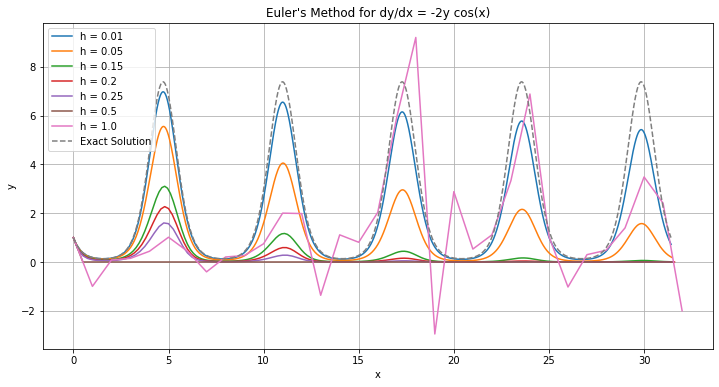

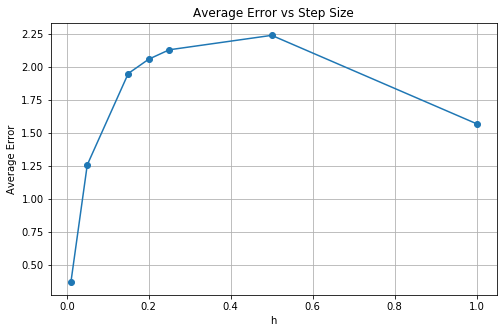

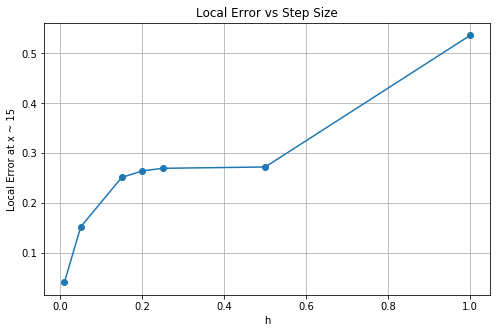

Comparison of y values near x = 15
h = 0.01 , Euler y = 0.23143958278779136
h = 0.05 , Euler y = 0.11986884462030582
h = 0.15 , Euler y = 0.02092133869634508
h = 0.2 , Euler y = 0.007903260555351253
h = 0.25 , Euler y = 0.0026622902905731154
h = 0.5 , Euler y = 0.0
h = 1.0 , Euler y = 0.8085930273257278


In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Define the differential equation
def f(x, y):
    return -2 * y * np.cos(x)

# Exact solution
def y_exact(x):
    return np.exp(-2 * np.sin(x))

# Parameters
h_values = [0.01, 0.05, 0.15, 0.2, 0.25, 0.5, 1.0]
x_start = 0
x_end = 10 * np.pi
y_0 = 1.0

# Lists to store errors
avg_errors = []
local_errors = []
y_at_15 = []

# Plot 1: Euler solutions for each h
plt.figure(figsize=(12, 6))

for h in h_values:
    x_values = np.arange(x_start, x_end + h, h)
    y_values = np.zeros(len(x_values))
    
    # Initial condition
    y_values[0] = y_0
    
    # Euler's Method loop
    for i in range(1, len(x_values)):
        x_n = x_values[i - 1]
        y_n = y_values[i - 1]
        y_values[i] = y_n + h * f(x_n, y_n)
    
    # Exact values
    y_true = y_exact(x_values)
    
    # Error for this run
    error = np.abs(y_values - y_true)
    avg_errors.append(np.mean(error))
    
    # Value near x = 15
    idx_15 = np.argmin(np.abs(x_values - 15))
    y_at_15.append(y_values[idx_15])
    local_errors.append(abs(y_values[idx_15] - y_true[idx_15]))
    
    # Plot Euler solution
    plt.plot(x_values, y_values, label='h = ' + str(h))

plt.plot(np.linspace(x_start, x_end, 1000), y_exact(np.linspace(x_start, x_end, 1000)),
         '--', label='Exact Solution')

plt.xlabel('x')
plt.ylabel('y')
plt.title("Euler's Method for dy/dx = -2y cos(x)")
plt.legend()
plt.grid(True)
plt.show()

# Plot 2: Average error vs h
plt.figure(figsize=(8, 5))
plt.plot(h_values, avg_errors, 'o-')
plt.xlabel('h')
plt.ylabel('Average Error')
plt.title('Average Error vs Step Size')
plt.grid(True)
plt.show()

# Plot 3: Local error at x ~ 15 vs h
plt.figure(figsize=(8, 5))
plt.plot(h_values, local_errors, 'o-')
plt.xlabel('h')
plt.ylabel('Local Error at x ~ 15')
plt.title('Local Error vs Step Size')
plt.grid(True)
plt.show()

# Print values near x = 15
print("Comparison of y values near x = 15")
for i in range(len(h_values)):
    print("h =", h_values[i], ", Euler y =", y_at_15[i])